## Model Explainability and Interpretability Analysis

This notebook focuses on interpreting and explaining the machine learning model used to predict financial exclusion risk in Kenya.

The analysis applies multiple explainability techniques including:

- SHAP (SHapley Additive exPlanations)
- Permutation Feature Importance
- Mutual Information Analysis

These methods help identify the key socioeconomic and demographic factors influencing financial exclusion predictions while improving transparency and trust in the predictive system.

## Why Explainability Matters

Machine learning models can achieve strong predictive performance but are often difficult to interpret.

Explainability techniques help reveal:
- how predictions are made
- which features influence predictions most
- how different variables affect financial exclusion risk.

This improves transparency, trust and practical decision-making.

## Loading the Model and Dataset

The trained Gradient Boosting pipeline and processed dataset are loaded for interpretability analysis.

In [48]:
import json
from pathlib import Path

ARTIFACTS_DIR = Path("../artifacts")

with open(ARTIFACTS_DIR / "04_model_metadata.json", "r") as f:
    metadata = json.load(f)

In [49]:
# Dataset Overview
# We preview the first rows of the dataset to understand its structure, features, and target variable.
from pathlib import Path
import pandas as pd

DATA_PATH = Path("../data/processed/finaccess_2021_modeling_base.csv")

df = pd.read_csv(DATA_PATH)
df.head()

,County,location_type,gender,education_level,marital_status,adults,financially_excluded,age,is_youth,is_rural_youth
0,Trans Nzoia,Rural,Female,Completed technical training after secondary s...,Widowed,1 adult Household,0,59,0,0
1,Busia,Rural,Female,Completed technical training after secondary s...,Married/Living with partner,>1 adult Household,0,43,0,0
2,Machakos,Rural,Male,Some primary,Divorced/separated,1 adult Household,1,72,0,0
3,Kisumu,Rural,Male,Primary completed,Single/Never Married,>1 adult Household,0,22,1,1
4,Nyeri,Urban,Male,Primary completed,Married/Living with partner,>1 adult Household,0,36,0,0


In [50]:
!pip install shap

In [60]:
# Importing required libraries for shap explainability

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance


In [63]:
import joblib

gb = joblib.load("gb_pipeline.pkl")

#### Extracting the Preprocessing Pipeline and Model

The preprocessing component and trained Gradient Boosting model are extracted from the saved pipeline.

The preprocessing pipeline is used to transform the dataset consistently, while the trained model is used for SHAP analysis, feature importance evaluation and interpretability tasks.

In [64]:
preprocessor = gb.named_steps["preprocess"]

model = gb.named_steps["model"]

In [65]:
df = pd.read_csv("../data/processed/finaccess_2021_modeling_base.csv")


In [59]:
df.columns

Index(['County', 'location_type', 'gender', 'education_level',
       'marital_status', 'adults', 'financially_excluded', 'age', 'is_youth',
       'is_rural_youth'],
      dtype='object')

In [66]:
X = df.drop("financially_excluded", axis=1)

y = df["financially_excluded"]

### Preparing the Data

The dataset is divided into training and testing subsets for explainability and feature importance analysis.

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#### Loading the Trained Model

The trained Gradient Boosting pipeline is loaded using `joblib`.

Loading the saved model allows the notebook to perform explainability and interpretability analysis without retraining the model.



In [68]:
gb = joblib.load("gb_pipeline.pkl")

print(gb)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['County', 'location_type', 'gender', 'education_level',
       'marital_status', 'adults'],
      dtype='object')),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                   

In [69]:
preprocessor = gb.named_steps["preprocess"]

model = gb.named_steps["model"]

### Feature Transformation

The preprocessing pipeline transforms categorical and numerical features into a format suitable for model interpretation.

In [70]:
X_test_transformed = preprocessor.transform(X_test)

print(X_test_transformed.shape)

(4181, 74)


In [71]:
X_sample = X_test.sample(100, random_state=42)

#### Transforming the Sample Dataset

The sampled test data is transformed using the preprocessing pipeline to ensure it matches the format expected by the trained model.

This transformation prepares the dataset for SHAP.

In [72]:
X_sample_transformed = preprocessor.transform(X_sample)

### SHAP Analysis

SHAP (SHapley Additive exPlanations) explains how individual features contribute to model predictions.

It helps identify:
- the most influential features,
- whether features increase or decrease exclusion risk,
- and how predictions vary across individuals.

#### Initializing the SHAP Explainer

A SHAP TreeExplainer is created using the trained Gradient Boosting model to generate feature contribution scores.

In [73]:
explainer = shap.TreeExplainer(model)

In [76]:
X_sample_transformed = preprocessor.transform(X_sample)

X_sample_transformed = X_sample_transformed.toarray()

X_sample_transformed = X_sample_transformed.astype(np.float64)

In [77]:
shap_values = explainer.shap_values(X_sample_transformed)

### Extracting Feature Names

The preprocessing pipeline generates transformed feature names after encoding categorical variables and preparing the dataset for modeling.

The `get_feature_names_out()` function retrieves the names of the transformed features used by the model.

Displaying the first few feature names helps improve interpretability by linking SHAP values and feature importance scores to meaningful variable names instead of generic labels such as `feature_1` or `feature_53`.

In [80]:
feature_names = preprocessor.get_feature_names_out()

feature_names[:10]

array(['cat__County_Baringo', 'cat__County_Bomet', 'cat__County_Bungoma',
       'cat__County_Busia', 'cat__County_Elgeyo-Marakwet',
       'cat__County_Embu', 'cat__County_Garissa', 'cat__County_Homabay',
       'cat__County_Isiolo', 'cat__County_Kajiado'], dtype=object)

In [83]:
clean_feature_names = [
    col.replace("num__", "").replace("cat__", "")
    for col in feature_names
]

### SHAP Feature Importance

The SHAP bar plot ranks features according to their average contribution to model predictions.

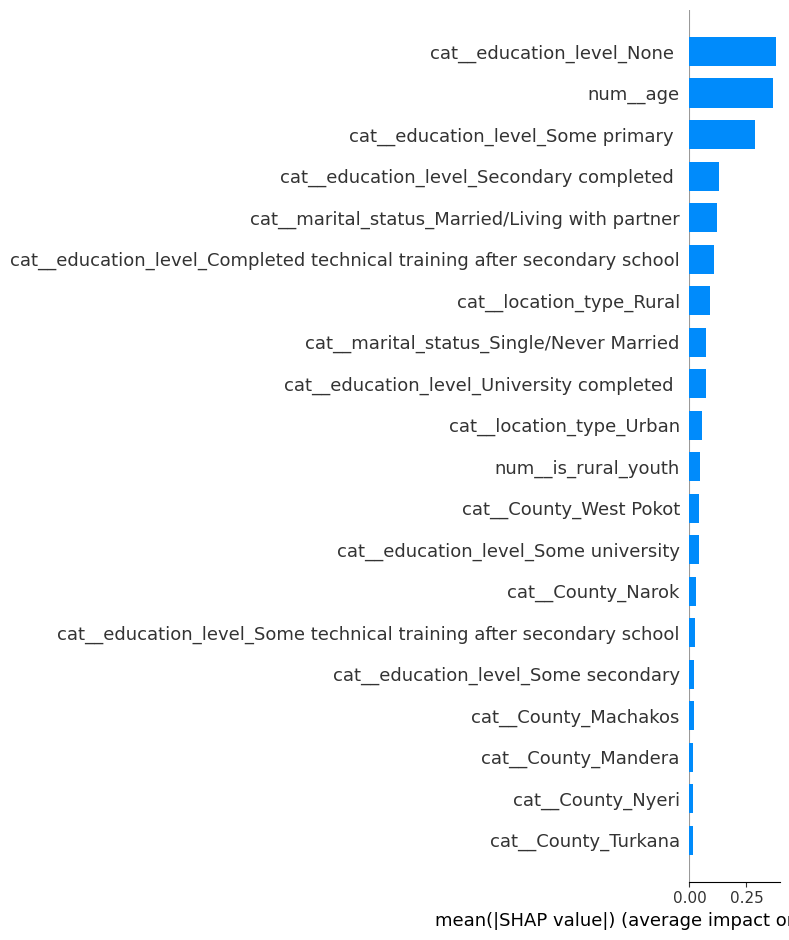

In [84]:
shap.summary_plot(
    shap_values,
    X_sample_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

### Permutation importance

#### Permutation Feature Importance

Permutation importance measures how model performance changes when feature values are randomly shuffled.

Features causing larger performance drops are considered more important.

In [85]:
perm_importance = permutation_importance(
    gb,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

### Creating the Permutation Importance Rankings

A DataFrame is created to combine feature names with their corresponding permutation importance scores.

The features are then sorted from highest to lowest importance to identify the variables that contribute most to model performance.

Displaying the top features helps highlight the strongest predictors of financial exclusion.

In [86]:
perm_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance.importances_mean
})

perm_df = perm_df.sort_values(
    by="Importance",
    ascending=False
)

perm_df.head(10)

,Feature,Importance
6,age,0.026692
3,education_level,0.012222
0,County,0.010667
1,location_type,0.003301
8,is_rural_youth,0.001292
5,adults,0.000670
2,gender,0.000335
7,is_youth,0.000000
4,marital_status,-0.000383


#### Permutation Importance Visualization

The following plot ranks features based on their contribution to prediction accuracy.

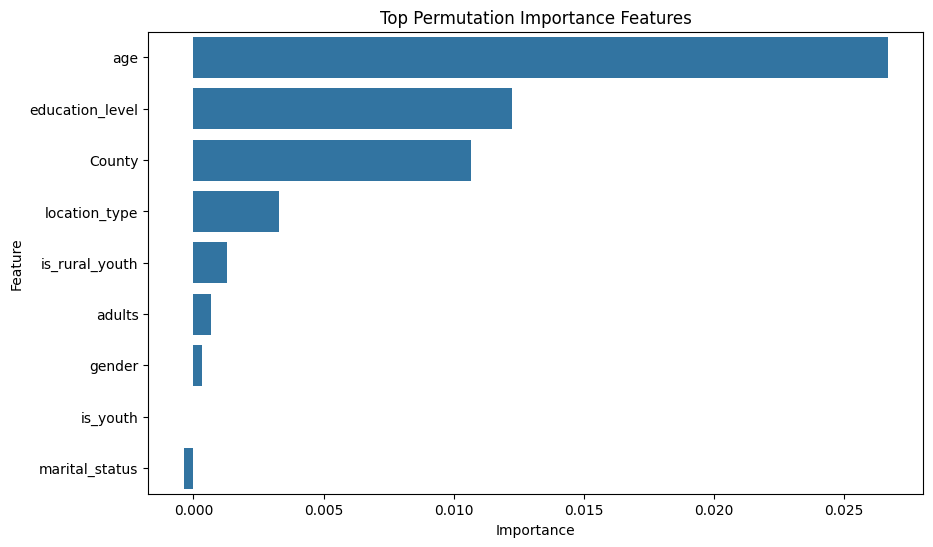

In [87]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=perm_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top Permutation Importance Features")

plt.show()

### Mutual Information Analysis

Mutual Information measures the statistical relationship between features and the target variable.

Higher scores indicate stronger predictive relationships.

#### Transforming Training Data for Explainability

The training dataset is transformed using the preprocessing pipeline to ensure consistency with the model training process.

The transformed sparse matrix is then converted into a dense numerical array and cast to `float64` format to make it compatible with SHAP and other interpretability techniques.

In [91]:
X_train_transformed = preprocessor.transform(X_train)

X_train_transformed = X_train_transformed.toarray()

X_train_transformed = X_train_transformed.astype(np.float64)

In [92]:
print(type(X_train_transformed))

print(X_train_transformed.dtype)

<class 'numpy.ndarray'>
float64


#### Calculating Mutual Information Scores

Mutual Information scores are computed to measure the relationship between input features and the target variable.

A sample of the transformed training dataset is used to improve computational efficiency while still identifying the features with the strongest predictive influence on financial exclusion.

In [99]:
mi_scores = mutual_info_classif(
    X_train_transformed[:1000],
    y_train[:1000]
)


#### Retrieving Feature Names

The transformed feature names are extracted from the preprocessing pipeline.

This helps map encoded variables to meaningful feature labels for interpretability analysis, visualization, and feature importance ranking.

In [100]:
mfeature_names = preprocessor.get_feature_names_out()

#### Creating Mutual Information Feature Rankings

A DataFrame is created to combine feature names with their corresponding Mutual Information scores.

The features are then sorted in descending order to identify the variables with the strongest predictive relationship to financial exclusion.

Displaying the top-ranked features helps highlight the most informative variables in the dataset.

In [101]:
mi_df = pd.DataFrame({
    "Feature": feature_names,
    "MI Score": mi_scores
})

mi_df = mi_df.sort_values(
    by="MI Score",
    ascending=False
)

mi_df.head(10)

,Feature,MI Score
71,num__age,0.048007
53,cat__education_level_None,0.026192
52,cat__education_level_Don't know (DO NOT READ OUT),0.020692
21,cat__County_Machakos,0.018986
26,cat__County_Migori,0.016276
62,cat__education_level_University completed,0.016054
16,cat__County_Kisumu,0.015750
30,cat__County_Nakuru,0.015682
41,cat__County_Trans Nzoia,0.014760
24,cat__County_Marsabit,0.014639


#### Mutual Information Rankings

The following visualization highlights the features with the highest Mutual Information scores.

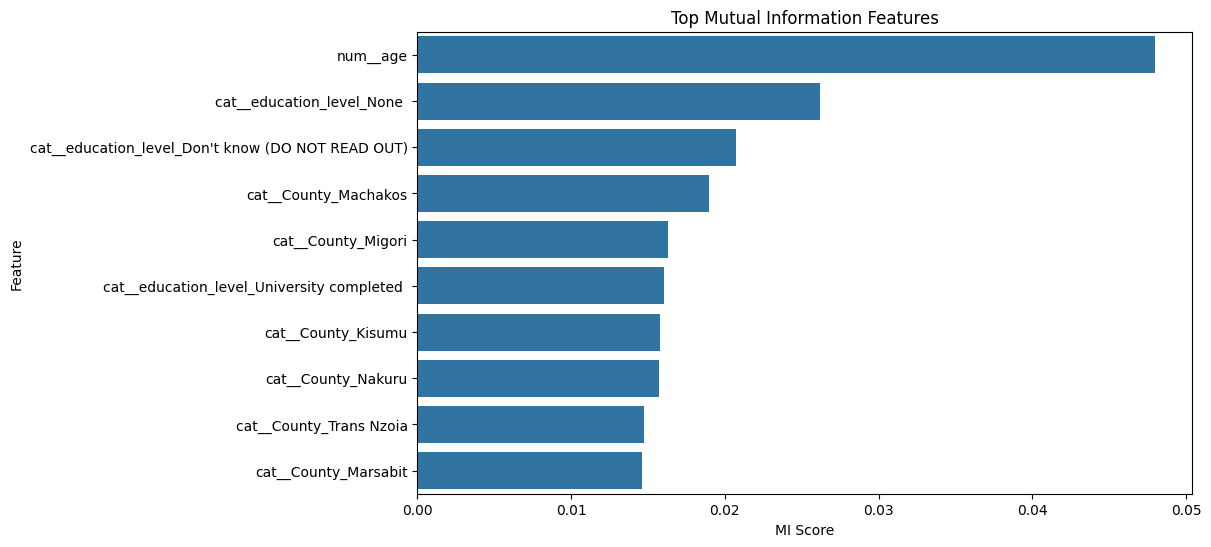

In [102]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=mi_df.head(10),
    x="MI Score",
    y="Feature"
)

plt.title("Top Mutual Information Features")

plt.show()

### Interpretability Conclusions

The explainability analysis identified key demographic and socioeconomic factors influencing financial exclusion predictions.

SHAP, permutation importance and mutual information provided complementary insights into model behavior and improved model transparency.

In [103]:
from pathlib import Path

Path("outputs").mkdir(exist_ok=True)

mi_df.to_csv(
    "outputs/mutual_information_scores.csv",
    index=False
)

perm_df.to_csv(
    "outputs/permutation_importance.csv",
    index=False
)